# 03. Linear Regression (Baseline)

As defined in Section B.1 of the proposal, we start with a simple Linear Regression.
This helps us identify which features are linearly correlated with the target and provides a clean performance floor.

**Key Requirements (per proposal):**
- Use `StandardScaler` in the pipeline.
- Evaluate with 5-fold Cross-Validation.
- Report MSE, MAE, and R².


## 1. Setup

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('Outputs dir:', OUT_DIR.resolve())

Outputs dir: /Users/bashkal/Desktop/ML/ML-Final/outputs


## 2. Load Engineered Features

In [2]:
# Section IV.C: Load Local Train set and Local Test set separately
try:
    train_df      = pd.read_parquet(OUT_DIR / 'train_local.parquet')
    test_local_df = pd.read_parquet(OUT_DIR / 'test_local.parquet')
    kaggle_test_df = pd.read_parquet(OUT_DIR / 'test_features.parquet')
    print('Loaded split parquet samples from', OUT_DIR.resolve())
except Exception as e:
    print('Parquet failed, trying CSV:', e)
    train_df      = pd.read_csv(OUT_DIR / 'all_train_local.csv')
    test_local_df = pd.read_csv(OUT_DIR / 'all_test_local.csv')
    kaggle_test_df = pd.read_csv(OUT_DIR / 'test_features.csv')
    print('Loaded CSV split samples from', OUT_DIR.resolve())

print(f'Shapes: train_local {train_df.shape} | test_local {test_local_df.shape} | kaggle_test {kaggle_test_df.shape}')
train_df.head()


Loaded split parquet samples from /Users/bashkal/Desktop/ML/ML-Final/outputs
Shapes: train_local (19497, 151) | test_local (4875, 151) | kaggle_test (24318, 150)


,PropertyID,NumReserveDays2016Q3,PropertyType,ListingType,Zipcode,Neighborhood,MetropolitanStatisticalArea,NumberofReviews,OverallRating,Bedrooms,Bathrooms,MaxGuests,ResponseRate,ResponseTimemin,Superhost,CancellationPolicy,SecurityDeposit,CleaningFee,ExtraPeopleFee,PublishedNightlyRate,PublishedMonthlyRate,PublishedWeeklyRate,MinimumStay,NumberofPhotos,BusinessReady,InstantbookEnabled,Latitude,Longitude,PropertyAgeDays,ReviewsPerMonth,PricePerGuest,WeeklyDiscount,MonthlyDiscount,BedBathRatio,ResponseRate_missing,ResponseTimemin_missing,SecurityDeposit_missing,CleaningFee_missing,ExtraPeopleFee_missing,OverallRating_missing,...,q1_wd_booked,q1_wd_price_mean,q1_we_booking_rate,q1_wd_booking_rate,q1_weekend_premium,q1_weekend_minus_weekday_book_rate,q2_we_days,q2_we_booked,q2_we_price_mean,q2_wd_days,q2_wd_booked,q2_wd_price_mean,q2_we_booking_rate,q2_wd_booking_rate,q2_weekend_premium,q2_weekend_minus_weekday_book_rate,q1_booked_m1,q1_booked_m2,q1_booked_m3,q2_booked_m4,q2_booked_m5,q2_booked_m6,q1_status_changes,q1_new_bookings,q1_booking_ends,q2_status_changes,q2_new_bookings,q2_booking_ends,h1_status_changes,h1_new_bookings,h1_booking_ends,recent_days,recent_booked,recent_available,recent_price_mean,recent_price_std,recent_booking_rate,recent_available_rate,price_change_q2_q1,booking_rate_change_q2_q1
0,10897656,0,Apartment,Private room,10018,Hell's Kitchen,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",0.0,NaN,1.0,1.0,2,93.0,207.47,0.0,Flexible,NaN,60.0,NaN,235,4900.0,1225.0,4,4.0,0.0,0.0,40.756152,-73.994263,156,0.000000,117.50,0.255319,0.304965,1.000000,0,0,1,0,1,1,...,3,97.368423,0.250000,0.157895,1.001351,0.092105,39,0,100.000000,52,0,100.000000,0.000000,0.000000,1.000000,0.000000,0,0,6,0,0,0,3,1,1,4,0,0,8,1,1,30.0,0.0,15.0,100.000000,0.000000,0.000000,0.500000,0.026490,-0.193548
1,7800905,0,Apartment,Private room,11211,Williamsburg,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",8.0,5.0,1.0,1.0,2,100.0,53.58,0.0,Strict,350.0,50.0,NaN,166,2100.0,545.0,2,12.0,0.0,0.0,40.710032,-73.960971,329,0.729483,83.00,0.530981,0.578313,1.000000,0,0,0,0,1,0,...,0,123.307693,0.000000,0.000000,0.819921,0.000000,27,0,98.666664,34,0,116.000000,0.000000,0.000000,0.850575,0.000000,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.048012,0.000000
2,10838516,37,House,Entire home/apt,11385,Ridgewood,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",0.0,NaN,1.0,1.5,2,NaN,NaN,NaN,Moderate,NaN,NaN,NaN,54,378.0,1512.0,1,16.0,1.0,0.0,40.700399,-73.897498,159,0.000000,27.00,-3.000000,0.766667,0.666667,1,1,1,1,1,1,...,20,54.000000,0.384615,0.384615,1.000000,0.000000,39,14,54.230770,52,16,54.326923,0.358974,0.307692,0.998230,0.051282,6,29,0,30,0,0,3,1,0,4,0,0,8,2,0,30.0,0.0,11.0,54.866665,1.357821,0.000000,0.366667,0.005291,-0.054945
3,6693888,0,Apartment,Entire home/apt,10016,Kips Bay,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",11.0,4.5,1.0,1.0,4,NaN,NaN,0.0,Flexible,500.0,50.0,NaN,175,3650.0,1300.0,3,18.0,1.0,0.0,40.742288,-73.979566,394,0.837563,43.75,-0.061224,0.304762,1.000000,1,1,0,0,1,0,...,11,172.211533,0.076923,0.211538,1.016192,-0.134615,39,7,178.333328,52,10,175.000000,0.179487,0.192308,1.019048,-0.012821,3,11,0,0,1,16,8,1,0,19,1,1,27,2,1,30.0,16.0,10.0,176.333328,2.248882,0.533333,0.333333,0.017427,0.032967
4,10149699,0,Apartment,Private room,11238,Bedford-Stuyvesant,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",1.0,5.0,1.0,1.0,2,NaN,NaN,NaN,Flexible,NaN,NaN,NaN,69,1932.0,483.0,1,5.0,0.0,0.0,40.681119,-73.956469,191,0.157068,34.50,0.000000,0.066667,1.000000,1,1,1,1,1,0,...,0,69.000000,0.000000,0.000000,1.022297,0.000000,39,0,69.000000,52,0,69.000000,0.000000,0.000000,1.000000,0.000000,0,0,0,0,0,0,4,0,0,0,0,0,4,0,0,30.0,0.0,30.0,69.000000,0.000000,0.000000,1.000000,-0.009465,0.000000


In [3]:

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [4]:
TARGET   = 'NumReserveDays2016Q3'
ID_COL   = 'PropertyID'
DROP_COLS = [ID_COL, TARGET]

y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=DROP_COLS)
X_kaggle_test = kaggle_test_df.drop(columns=[ID_COL])
kaggle_test_ids = kaggle_test_df[ID_COL].values

# Align columns (test should have identical columns to train X)
missing_in_test = [c for c in X.columns if c not in X_kaggle_test.columns]
extra_in_test   = [c for c in X_kaggle_test.columns if c not in X.columns]
print('Missing in kaggle test:', missing_in_test)
print('Extra   in kaggle test:', extra_in_test)
X_kaggle_test = X_kaggle_test.reindex(columns=X.columns)
print('After align — X:', X.shape, '| X_kaggle_test:', X_kaggle_test.shape)


Missing in kaggle test: []
Extra   in kaggle test: []
After align — X: (19497, 149) | X_kaggle_test: (24318, 149)


## 3. Preprocessing `ColumnTransformer`
- **Numerics:** median imputation. Tree-based models don't need scaling.
- **Categoricals:** fill `NaN` with `'missing'`, then OneHotEncode (`handle_unknown='ignore'`).
- The whole thing lives in a Pipeline so that imputation is fit only on training folds (no leakage).

In [5]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# Cap very-high-cardinality categoricals (e.g., Zipcode, Neighborhood) by
# keeping only the top-K most-frequent values for OneHot; rare values become 'Other'.
TOPK = 30
for c in cat_cols:
    top_values = X[c].value_counts(dropna=False).head(TOPK).index
    X[c]             = X[c].where(X[c].isin(top_values), other='Other')
    X_kaggle_test[c] = X_kaggle_test[c].where(X_kaggle_test[c].isin(top_values), other='Other')

print(f'Numeric cols    : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}')
print('Categorical examples:', cat_cols[:10])


Numeric cols    : 143
Categorical cols: 6
Categorical examples: ['PropertyType', 'ListingType', 'Neighborhood', 'MetropolitanStatisticalArea', 'CancellationPolicy', 'geo_cluster']


In [6]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('Preprocessor ready.')


Preprocessor ready.


## 4. 5-Fold CV Evaluation

Helper that runs one model through CV and returns OOF predictions + mean MSE.

In [7]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []

def evaluate_model(name, model, X, y, kf=kf):
    pipe = Pipeline(steps=[
        ('prep',  preprocessor),
        ('model', model),
    ])
    t0 = time.time()
    fold_mses = []
    fold_maes = []
    fold_r2s  = []
    oof = np.zeros(len(y))
    
    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[va])
        pred = np.clip(pred, 0, 92)   # target is bounded in [0, 92]
        oof[va] = pred
        
        mse = mean_squared_error(y[va], pred)
        mae = mean_absolute_error(y[va], pred)
        r2  = r2_score(y[va], pred)
        
        fold_mses.append(mse)
        fold_maes.append(mae)
        fold_r2s.append(r2)
        print(f'  fold {fold+1}: MSE = {mse:.3f} | MAE = {mae:.3f} | R2 = {r2:.3f}')
        
    elapsed = time.time() - t0
    mean_mse = float(np.mean(fold_mses))
    std_mse  = float(np.std(fold_mses))
    mean_mae = float(np.mean(fold_maes))
    mean_r2  = float(np.mean(fold_r2s))
    
    print(f'\n{name:>22s} | MSE = {mean_mse:7.3f} (±{std_mse:.3f}) | MAE = {mean_mae:7.3f} | R2 = {mean_r2:7.3f} | {elapsed:5.1f}s')
    np.save(OUT_DIR / f'oof_{name}.npy', oof)
    
    return {'name': name, 'mse_mean': mean_mse, 'mse_std': std_mse, 'mae_mean': mean_mae, 'r2_mean': mean_r2,
            'seconds': elapsed, 'oof': oof}

### 4.0 LinearRegression (Section IV.B Baseline)
The simplest model to check for linear relationships between features and the target count.


### 4.0 Constant-Mean Baseline (Section IV.C)
As specified in our experimental design, we first establish a trivial baseline by predicting the mean of the training set for every observation. This measures the minimum improvement our actual models must provide.


In [8]:
# Constant-Mean Baseline
mean_val = np.mean(y)
pred_mean = np.full_like(y, mean_val)

mse_mean = mean_squared_error(y, pred_mean)
mae_mean = mean_absolute_error(y, pred_mean)
r2_mean  = r2_score(y, pred_mean) # Should be 0.0 by definition

results.append({
    'name': 'ConstantMean',
    'mse_mean': mse_mean,
    'mse_std': 0.0,
    'mae_mean': mae_mean,
    'r2_mean': r2_mean,
    'seconds': 0.0,
    'oof': pred_mean
})

print(f"Constant-Mean Baseline | MSE = {mse_mean:.3f} | MAE = {mae_mean:.3f} | R2 = {r2_mean:.3f}")


Constant-Mean Baseline | MSE = 772.739 | MAE = 22.801 | R2 = 0.000


In [9]:
lr_model = LinearRegression()
results.append(evaluate_model('LinearRegression', lr_model, X, y))


  fold 1: MSE = 205.616 | MAE = 9.029 | R2 = 0.723
  fold 2: MSE = 201.442 | MAE = 9.143 | R2 = 0.740
  fold 3: MSE = 202.498 | MAE = 9.104 | R2 = 0.738
  fold 4: MSE = 212.755 | MAE = 9.350 | R2 = 0.727
  fold 5: MSE = 215.745 | MAE = 9.484 | R2 = 0.728

      LinearRegression | MSE = 207.611 (±5.671) | MAE =   9.222 | R2 =   0.731 |   1.8s


## 5. Results Summary

In [10]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'oof'} for r in results])
results_df = results_df.sort_values('mse_mean').reset_index(drop=True)
results_df.to_csv(OUT_DIR / 'baseline_cv_results.csv', index=False)
print('CV results (sorted by MSE):')
results_df

CV results (sorted by MSE):


,name,mse_mean,mse_std,mae_mean,r2_mean,seconds
0,LinearRegression,207.611313,5.670924,9.222140,0.731218,1.77771
1,ConstantMean,772.739122,0.000000,22.800946,0.000000,0.00000


In [11]:
# Manual refit for Linear Regression
lr_pipe = Pipeline(steps=[('prep', preprocessor), ('model', lr_model)])
lr_pipe.fit(X, y)
test_pred = np.clip(lr_pipe.predict(X_kaggle_test), 0, 92)

sub = pd.DataFrame({'Property[Q3]_test': kaggle_test_ids, 'Pred': test_pred})
out_path = OUT_DIR / 'submission_baseline_LinearRegression.csv'
sub.to_csv(out_path, index=False)
print(f'Saved {out_path.name}')


Saved submission_baseline_LinearRegression.csv


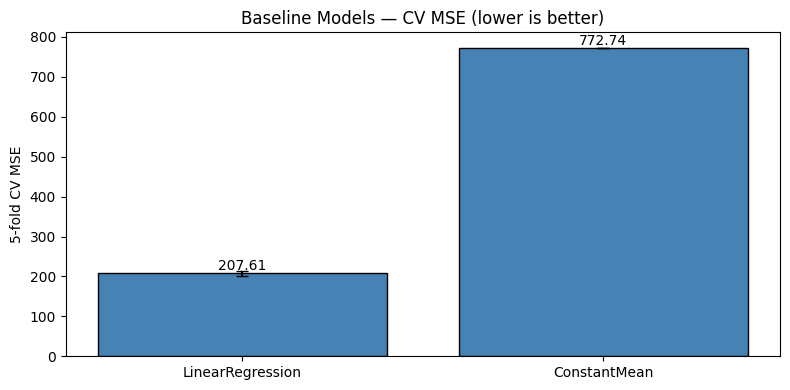

In [12]:
# Quick bar plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['name'], results_df['mse_mean'],
       yerr=results_df['mse_std'], capsize=4, color='steelblue', edgecolor='black')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('Baseline Models — CV MSE (lower is better)')
for i, v in enumerate(results_df['mse_mean']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_cv_bar.png', dpi=120); plt.show()

## 6. Refit Best Model on Full Train → Kaggle Submission

In [13]:
best_name = results_df.iloc[0]['name']
# Added LinearRegression to the dictionary to avoid KeyError
best_model_obj = {
    'LinearRegression': lr_model,
}[best_name]

print(f'Best baseline: {best_name} (CV MSE = {results_df.iloc[0]["mse_mean"]:.3f})')

best_pipe = Pipeline(steps=[('prep', preprocessor), ('model', best_model_obj)])
best_pipe.fit(X, y)
test_pred = np.clip(best_pipe.predict(X_kaggle_test), 0, 92)
print('Kaggle test predictions shape:', test_pred.shape)
print('First 10 preds:', test_pred[:10].round(2))


Best baseline: LinearRegression (CV MSE = 207.611)
Kaggle test predictions shape: (24318,)
First 10 preds: [ 0.   56.52  6.92 34.25 24.75  2.4   0.   92.   75.93 38.52]


In [14]:
# Per-model submissions (refit each on full train) — handy to compare on the public LB.
all_models = {
    'LinearRegression': lr_model,
}

for name, model in all_models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X, y)
    pred = np.clip(pipe.predict(X_kaggle_test), 0, 92)
    sub = pd.DataFrame({'Property[Q3]_test': kaggle_test_ids, 'Pred': pred})
    out_path = OUT_DIR / f'submission_baseline_{name}.csv'
    sub.to_csv(out_path, index=False)
    print(f'Saved {out_path.name} | mean={pred.mean():.2f}  zeros={(pred < 0.5).mean()*100:.1f}%')


Saved submission_baseline_LinearRegression.csv | mean=18.83  zeros=23.7%


In [15]:
# 7. Evaluate on Local Test Set (Section IV.C)
X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].astype(float).values
X_test_local = X_test_local.reindex(columns=X.columns)

# Evaluate Linear Regression
y_test_pred_lr = np.clip(lr_pipe.predict(X_test_local), 0, 92)
test_mse_lr = mean_squared_error(y_test_local, y_test_pred_lr)
test_mae_lr = mean_absolute_error(y_test_local, y_test_pred_lr)
test_r2_lr  = r2_score(y_test_local, y_test_pred_lr)

print(f"--- Unbiased Local Test Results (Linear Regression) ---")
print(f"Local Test MSE: {test_mse_lr:.3f}")
print(f"Local Test MAE: {test_mae_lr:.3f}")
print(f"Local Test R2 : {test_r2_lr:.3f}")

# Save for blend
np.save(OUT_DIR / 'test_local_pred_LinearRegression.npy', y_test_pred_lr)

# Verify Constant-Mean performance on the local test set
mean_test_pred = np.full_like(y_test_local, np.mean(y)) # Use training mean
test_mse_const = mean_squared_error(y_test_local, mean_test_pred)
print(f"\nConstant-Mean Local Test MSE: {test_mse_const:.3f}")

--- Unbiased Local Test Results (Linear Regression) ---
Local Test MSE: 206.475
Local Test MAE: 9.300
Local Test R2 : 0.729

Constant-Mean Local Test MSE: 763.012


In [16]:
# Verify submission format
sub = pd.read_csv(OUT_DIR / f'submission_baseline_{best_name}.csv')
print('Header :', list(sub.columns))
print('Rows   :', len(sub))
print('NaNs   :', sub.isna().sum().sum())
print('Range  :', sub['Pred'].min(), '→', sub['Pred'].max())
sub.head()

Header : ['Property[Q3]_test', 'Pred']
Rows   : 24318
NaNs   : 0
Range  : 0.0 → 92.0


,Property[Q3]_test,Pred
0,795,0.000000
1,2515,56.521761
2,2595,6.915686
3,5099,34.253585
4,5107,24.747393


## 7. Permutation Feature Importance (Best Model)
Quick sanity check: do the features we expect to matter (Q2 booking rate, recent window, reviews) actually drive predictions?

In [17]:
# Use the local test set for permutation importance calculation
# This follows Section IV.C by evaluating feature importance on unseen data.
X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].astype(float).values

best_pipe.fit(X, y) # refit on dev set
perm = permutation_importance(best_pipe, X_test_local, y_test_local,
                              n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE,
                              scoring='neg_mean_squared_error')
imp = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)
imp.head(25)


,feature,importance,std
72,q2_price_mean,71805.046335,1240.613511
120,q2_wd_price_mean,23162.292142,364.556257
53,q1_price_mean,17040.626247,285.374044
117,q2_we_price_mean,14002.109148,219.500499
80,q2_booking_rate,6611.844438,60.203436
61,q1_booking_rate,6222.173081,67.478182
121,q2_we_booking_rate,5728.966918,63.056758
122,q2_wd_booking_rate,5717.868233,65.392146
110,q1_wd_price_mean,5465.700005,79.976301
111,q1_we_booking_rate,4498.530984,60.403432


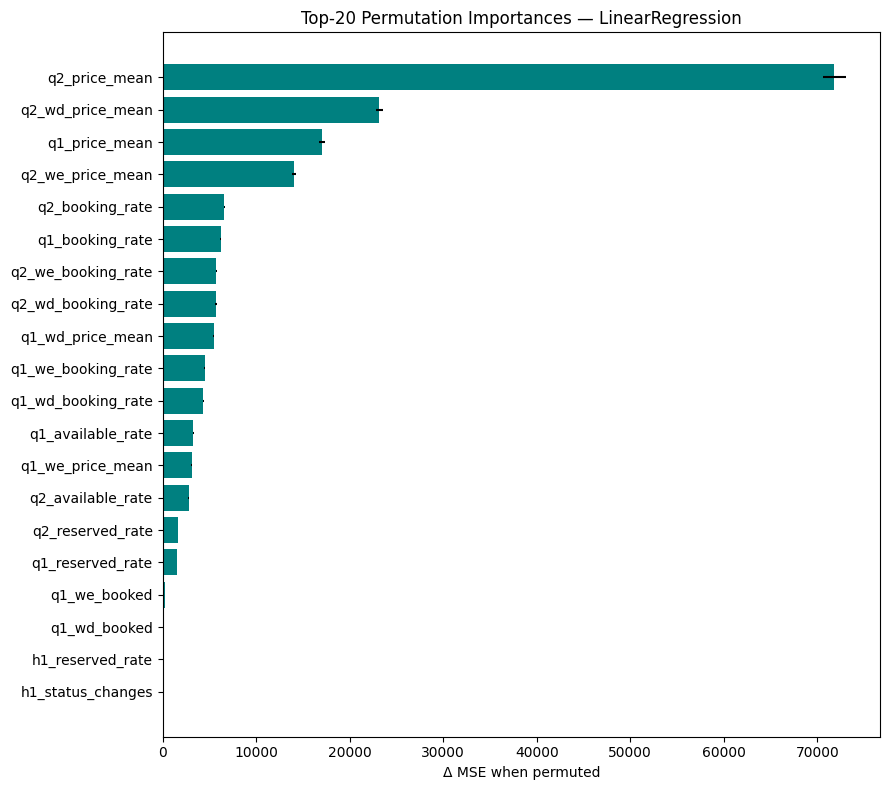

In [18]:
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='teal')
ax.set_title(f'Top-20 Permutation Importances — {best_name}')
ax.set_xlabel('Δ MSE when permuted')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_perm_importance.png', dpi=120); plt.show()

## Summary & Next Step

We now have:
- A reproducible, leakage-free `Pipeline` covering imputation + encoding.
- CV score for **Linear Regression** as our baseline floor.
- Out-of-fold predictions saved for the baseline.
- Linear model submission file ready for Kaggle.

### → [04_Random_Forest.ipynb](04_Random_Forest.ipynb)
Next we'll:
1. Implement the first non-linear model: **Random Forest** (Section B.2).
2. Compare its performance to this linear baseline.


## 8. Section IV.C — Unbiased Local Test Evaluation
As specified in our experimental design, we now evaluate our refit baseline model on the 20% local test set that was never seen during CV or tuning.


In [19]:
# Evaluate on Local Test
X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].astype(float).values

# Align columns with training data X
X_test_local = X_test_local.reindex(columns=X.columns, fill_value=0)

# Apply same categorical capping as done for X (top values calculated from train_df)
for c in cat_cols:
    top_values = train_df[c].value_counts(dropna=False).head(TOPK).index
    X_test_local[c] = X_test_local[c].where(X_test_local[c].isin(top_values), other='Other')

test_local_pred = np.clip(best_pipe.predict(X_test_local), 0, 92)
test_local_mse  = mean_squared_error(y_test_local, test_local_pred)
test_local_mae  = mean_absolute_error(y_test_local, test_local_pred)
test_local_r2   = r2_score(y_test_local, test_local_pred)

print(f"--- Unbiased Local Test Results ({best_name}) ---")
print(f"Local Test MSE: {test_local_mse:.3f}")
print(f"Local Test MAE: {test_local_mae:.3f}")
print(f"Local Test R2 : {test_local_r2:.3f}")

# Save local test predictions for blending
np.save(OUT_DIR / 'test_local_pred_LinearRegression.npy', test_local_pred)

--- Unbiased Local Test Results (LinearRegression) ---
Local Test MSE: 206.369
Local Test MAE: 9.288
Local Test R2 : 0.729
